# IIR 필터 시각화 — V1부터 V8까지 단계별로

**이 노트북의 목표**

1. **임펄스가 필터를 지나면 시간축으로 "퍼진다"** — 왜? (V8, 그리고 핵심 데모)
2. **주파수마다 위상 지연이 다르다** → 그래서 phase response가 주파수마다 달라진다 (V4, V5, 핵심 데모)

**구성:**
- V1 사인파 + 입출력 → V2 Butterworth → V3 Magnitude → V4 Phase → V5 Group Delay
- V6 슬라이더 → V7 필터 종류 전환 → V8 Impulse/Step Response
- **핵심 데모**: 위 두 가지를 눈으로 확인하는 셀 (제일 중요!)

위에서부터 순서대로 실행하세요.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11
np.set_printoptions(precision=4, suppress=True)

FS = 1000          # sampling rate [Hz] (낮게 잡아 보기 쉽게)
NYQ = FS / 2       # Nyquist = 500 Hz
print(f"fs = {FS} Hz, Nyquist = {NYQ} Hz")

fs = 1000 Hz, Nyquist = 500.0 Hz


## V1 — 사인파 생성 + 입력/출력 표시

가장 단순한 출발점. 사인파를 만들고, 아직 필터는 안 거친 상태로 그려본다.
(출력 = 입력, 나중에 필터를 넣으면 여기가 달라진다)


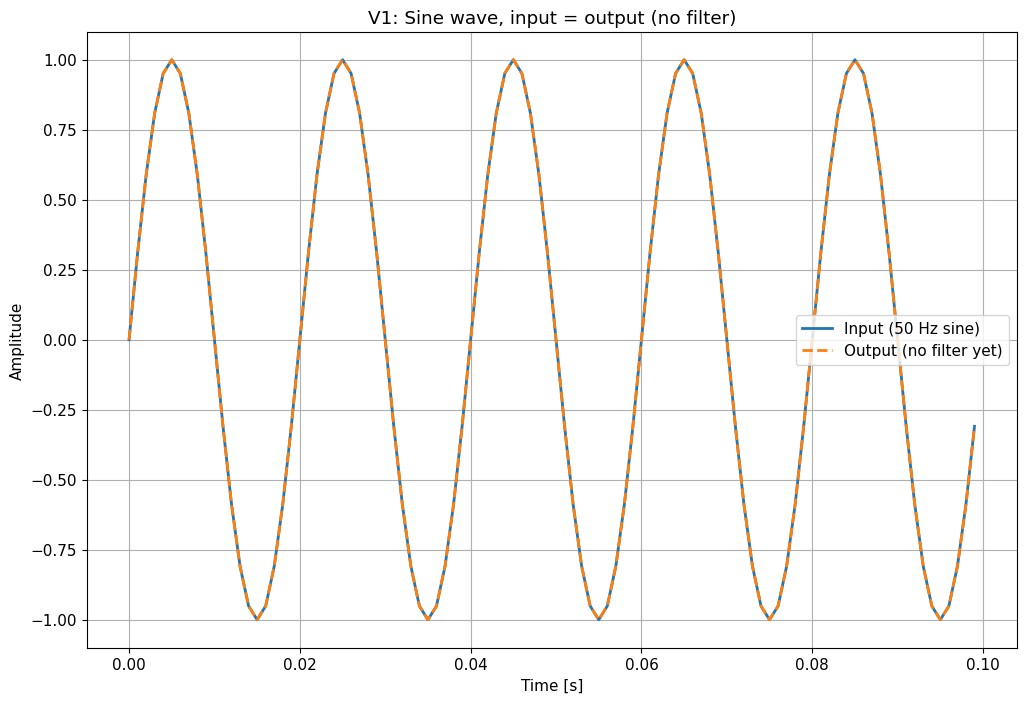

In [10]:
def make_sine(freq, fs=FS, dur=0.1):
    t = np.arange(0, dur, 1/fs)
    return t, np.sin(2*np.pi*freq*t)

t, x = make_sine(50)          # 50 Hz sine
y = x.copy()                  # V1: no filter yet, output = input

plt.figure()
plt.plot(t, x, label='Input (50 Hz sine)', lw=2)
plt.plot(t, y, '--', label='Output (no filter yet)', lw=2)
plt.xlabel('Time [s]'); plt.ylabel('Amplitude')
plt.title('V1: Sine wave, input = output (no filter)')
plt.legend(); plt.show()

## V2 — Butterworth 필터 추가

이제 필터를 통과시킨다. **출력이 입력과 달라지는 두 가지**를 관찰:

1. **진폭이 줄어듦** (magnitude 변화)
2. **시간상 밀림 (지연)** ← 이게 위상(phase)의 정체!

low-pass의 cutoff 아래/위 주파수를 바꿔가며 비교해보자.


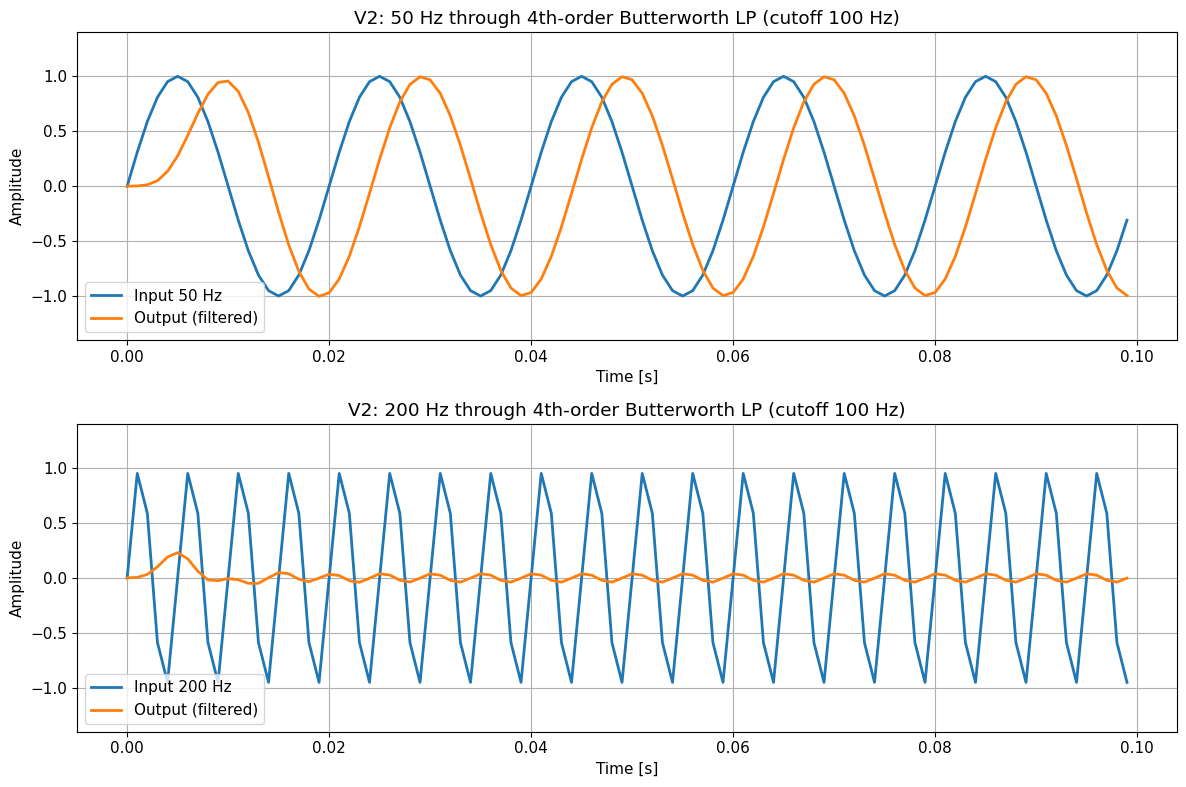

위: 50Hz는 통과대역 -> 크기 거의 유지, 하지만 살짝 밀림(지연)
아래: 200Hz는 차단대역 -> 크기 크게 줄고, 더 많이 밀림


In [11]:
def butter_lp(cutoff_hz, order=4, fs=FS):
    b, a = signal.butter(order, cutoff_hz/(fs/2), btype='low')
    return b, a

b, a = butter_lp(cutoff_hz=100, order=4)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
for ax, f0 in zip(axes, [50, 200]):     # 50Hz(통과), 200Hz(차단)
    t, x = make_sine(f0)
    y = signal.lfilter(b, a, x)
    ax.plot(t, x, label=f'Input {f0} Hz', lw=2)
    ax.plot(t, y, label='Output (filtered)', lw=2)
    ax.set_xlabel('Time [s]'); ax.set_ylabel('Amplitude')
    ax.set_title(f'V2: {f0} Hz through 4th-order Butterworth LP (cutoff 100 Hz)')
    ax.legend(); ax.set_ylim(-1.4, 1.4)
plt.tight_layout(); plt.show()

print("위: 50Hz는 통과대역 -> 크기 거의 유지, 하지만 살짝 밀림(지연)")
print("아래: 200Hz는 차단대역 -> 크기 크게 줄고, 더 많이 밀림")

- 지연을 측정하는 건  시작점끼리 비교하는것이 아라, 파형이 안정된 뒤 
peak나 zero-crossing(영점)이 얼마나 밀렸나를 보는 것


## V3 — Magnitude Response 추가

각 주파수가 **몇 배로 통과**되는지 (크기 응답). `freqz`로 계산.


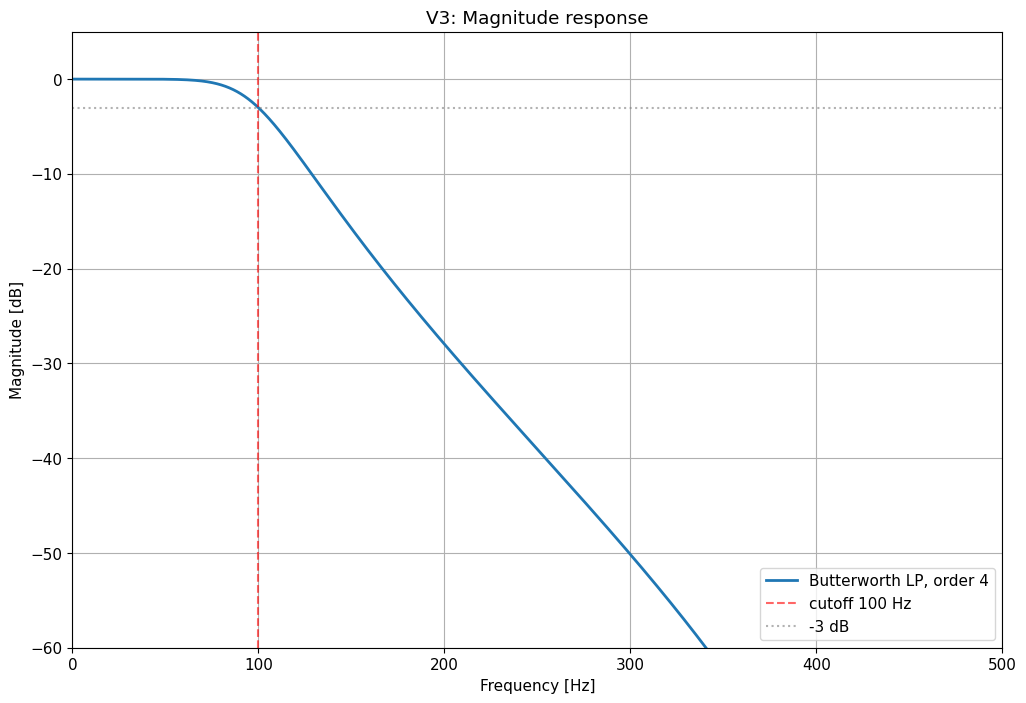

In [12]:
def plot_mag(b, a, fs=FS, ax=None, label=None):
    w, h = signal.freqz(b, a, worN=2000)
    f = w * fs / (2*np.pi)                 # rad/sample -> Hz
    mag_db = 20*np.log10(np.abs(h) + 1e-12)
    if ax is None:
        _, ax = plt.subplots()
    ax.plot(f, mag_db, lw=2, label=label)
    ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('Magnitude [dB]')
    ax.set_xlim(0, fs/2); ax.set_ylim(-60, 5)
    return ax

b, a = butter_lp(100, order=4)
ax = plot_mag(b, a, label='Butterworth LP, order 4')
ax.axvline(100, color='r', ls='--', alpha=0.6, label='cutoff 100 Hz')
ax.axhline(-3, color='gray', ls=':', alpha=0.6, label='-3 dB')
ax.set_title('V3: Magnitude response')
ax.legend(); plt.show()

## V4 — Phase Response 추가 ★

**Goeun이 이해하고 싶어한 부분 (1/2)**

phase response = **각 주파수가 얼마나 "회전(각도)" 밀리는가**.

- `np.angle(h)` : 각 주파수의 위상 (라디안)
- `np.unwrap(...)` : ±π 경계에서 끊기는 걸 이어붙임

**핵심**: 위상이 주파수마다 **다르게** 밀린다. 그래프가 직선이 아니라 휘어진 곡선이면 → 주파수마다 지연 시간이 다르다는 뜻 (= 위상 왜곡).


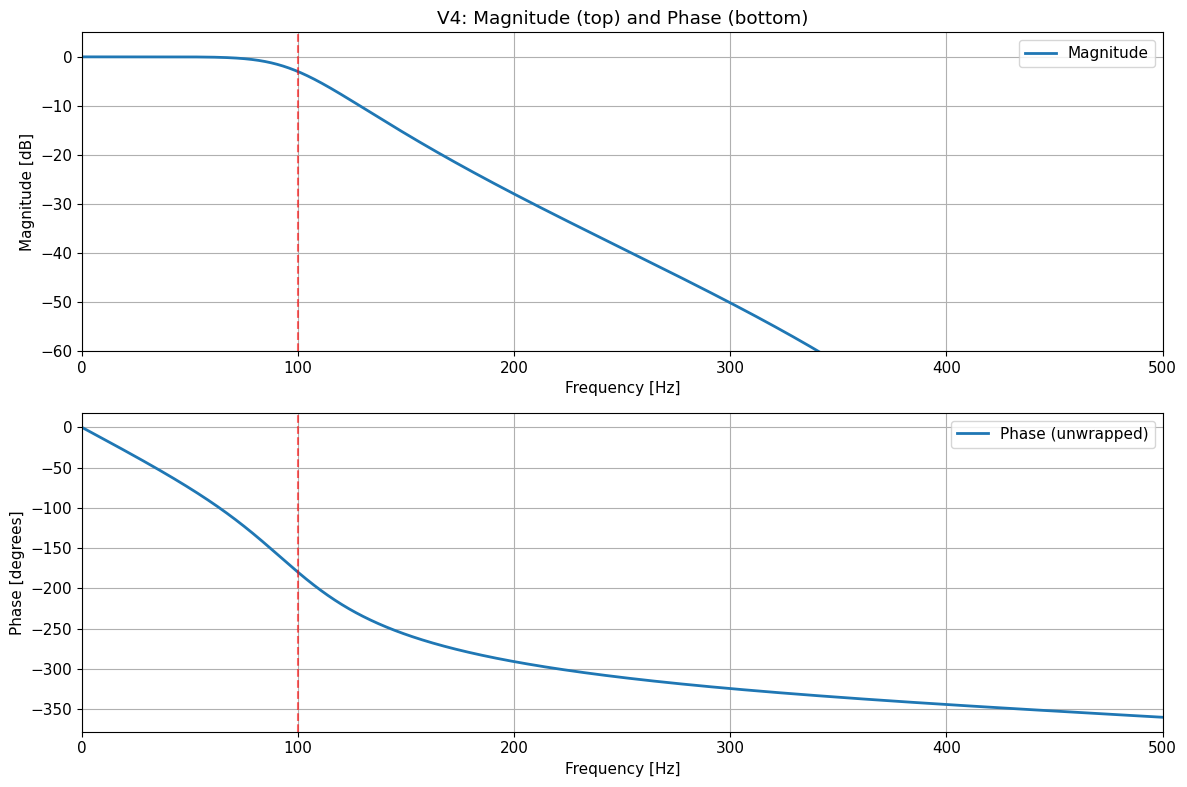

Phase가 직선이 아니라 휘어진 곡선 -> IIR은 linear phase가 아님
=> 주파수마다 밀리는 정도가 제각각 (위상 왜곡)


In [13]:
def plot_phase(b, a, fs=FS, ax=None, label=None):
    w, h = signal.freqz(b, a, worN=2000)
    f = w * fs / (2*np.pi)
    phase = np.unwrap(np.angle(h))          # unwrap: 끊김 이어붙이기
    if ax is None:
        _, ax = plt.subplots()
    ax.plot(f, np.rad2deg(phase), lw=2, label=label)
    ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('Phase [degrees]')
    ax.set_xlim(0, fs/2)
    return ax

b, a = butter_lp(100, order=4)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_mag(b, a, ax=ax1, label='Magnitude')
ax1.axvline(100, color='r', ls='--', alpha=0.6)
ax1.set_title('V4: Magnitude (top) and Phase (bottom)')
ax1.legend()

plot_phase(b, a, ax=ax2, label='Phase (unwrapped)')
ax2.axvline(100, color='r', ls='--', alpha=0.6)
ax2.legend()
plt.tight_layout(); plt.show()

print("Phase가 직선이 아니라 휘어진 곡선 -> IIR은 linear phase가 아님")
print("=> 주파수마다 밀리는 정도가 제각각 (위상 왜곡)")

## V5 — Group Delay 추가 ★★

**Goeun이 이해하고 싶어한 부분 (2/2) — 여기가 핵심!**

phase는 "각도"라서 직관적이지 않다. **group delay는 그걸 "시간(샘플/초)"으로 바꾼 것.**

$$\text{group delay} = -\frac{d(\text{phase})}{d\omega}$$

**읽는 법:**
- group delay가 **평평** → 모든 주파수가 같은 시간 지연 (= linear phase)
- group delay가 **울퉁불퉁** → 주파수마다 지연 시간이 다름 (= 위상 왜곡)

Butterworth(IIR)는 평평하지 않다 → **주파수마다 지연이 다르다** = Goeun이 이해하려던 그것!


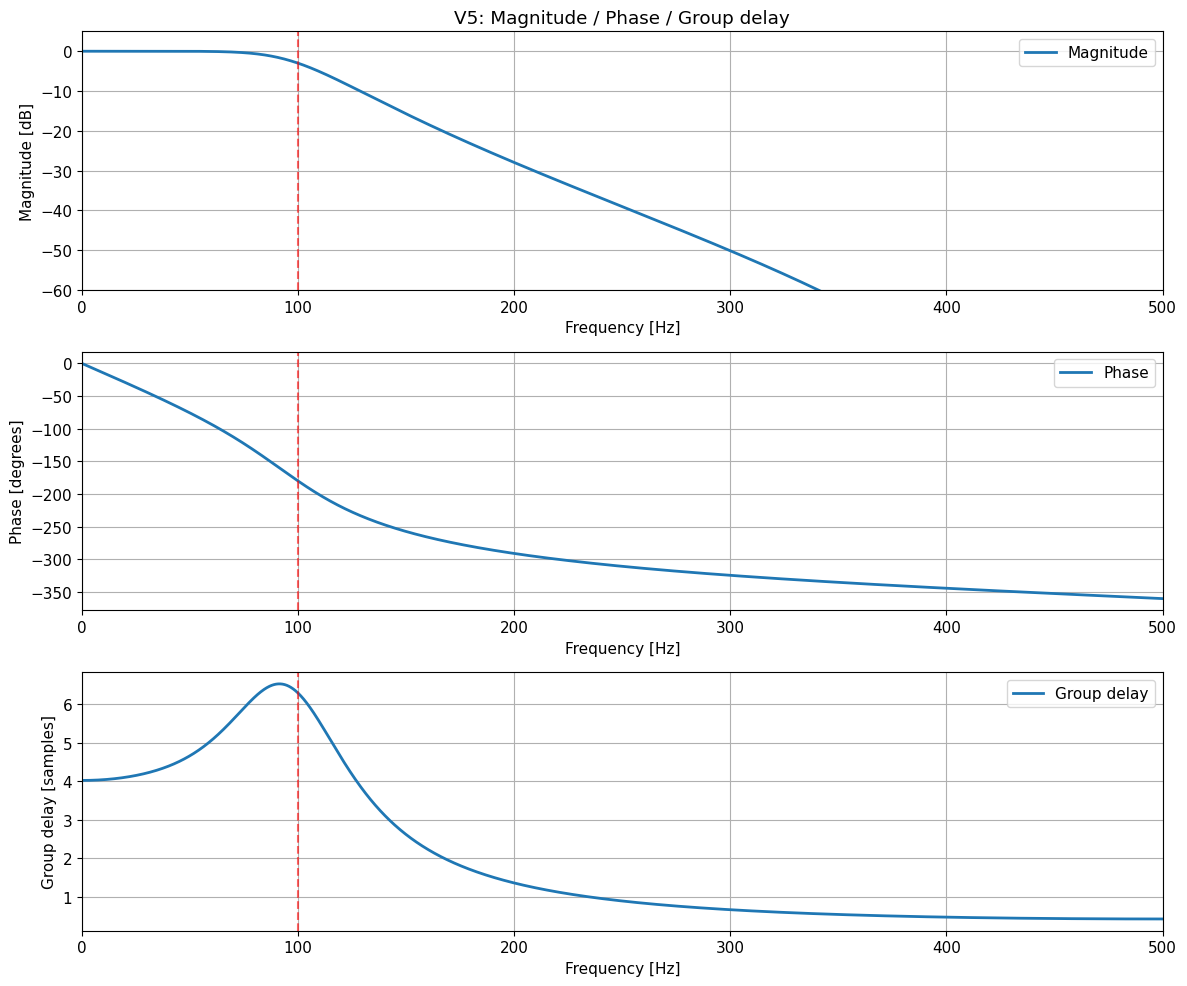

  20 Hz -> group delay =   4.10 samples =   4.10 ms
  50 Hz -> group delay =   4.66 samples =   4.66 ms
 100 Hz -> group delay =   6.29 samples =   6.29 ms
 150 Hz -> group delay =   2.61 samples =   2.61 ms
 200 Hz -> group delay =   1.36 samples =   1.36 ms

=> 주파수마다 지연 시간이 다르다! (평평하지 않음)


In [14]:
def plot_gdelay(b, a, fs=FS, ax=None, label=None):
    w, gd = signal.group_delay((b, a), w=2000)
    f = w * fs / (2*np.pi)
    if ax is None:
        _, ax = plt.subplots()
    ax.plot(f, gd, lw=2, label=label)          # 단위: 샘플
    ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('Group delay [samples]')
    ax.set_xlim(0, fs/2)
    return ax

b, a = butter_lp(100, order=4)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))
plot_mag(b, a, ax=ax1, label='Magnitude'); ax1.axvline(100, color='r', ls='--', alpha=0.6)
ax1.set_title('V5: Magnitude / Phase / Group delay')
plot_phase(b, a, ax=ax2, label='Phase'); ax2.axvline(100, color='r', ls='--', alpha=0.6)
plot_gdelay(b, a, ax=ax3, label='Group delay'); ax3.axvline(100, color='r', ls='--', alpha=0.6)
for a_ in (ax1, ax2, ax3): a_.legend()
plt.tight_layout(); plt.show()

# 특정 주파수들의 group delay를 숫자로
w, gd = signal.group_delay((b, a), w=2000)
f = w * FS / (2*np.pi)
for f0 in [20, 50, 100, 150, 200]:
    i = np.argmin(np.abs(f - f0))
    print(f"{f0:>4} Hz -> group delay = {gd[i]:6.2f} samples = {gd[i]/FS*1000:6.2f} ms")
print("\n=> 주파수마다 지연 시간이 다르다! (평평하지 않음)")

---
# ★★★ 핵심 데모 1 — "주파수마다 위상 지연이 다르다"를 눈으로

group delay 숫자만 보면 와닿지 않는다. **직접 여러 주파수 사인파를 넣어서, 각각 얼마나 밀리는지 측정**해보자.

같은 필터에 20Hz, 50Hz, 100Hz, 150Hz 사인파를 각각 넣고 **실제로 밀린 시간**을 재면 → 다 다르다.


주파수별 실제 지연 측정 (첫 피크 위치로):

  20 Hz -> 약   4 samples =   4.0 ms 밀림
  50 Hz -> 약   4 samples =   4.0 ms 밀림
 100 Hz -> 약   6 samples =   6.0 ms 밀림
 150 Hz -> 약   4 samples =   4.0 ms 밀림


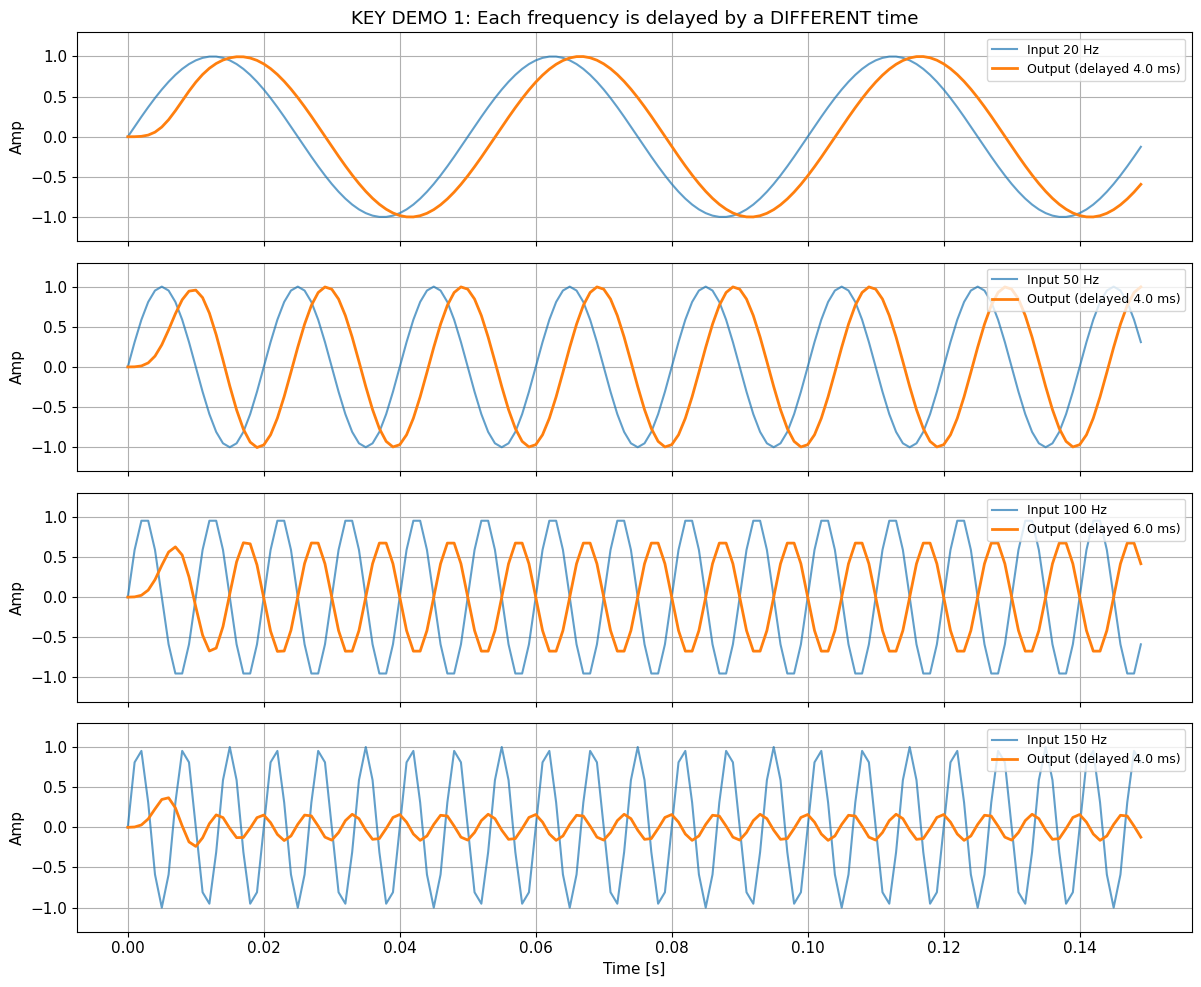


=> 같은 필터인데 주파수마다 밀리는 시간이 다름!
=> 이것이 phase response가 주파수마다 다른 이유 (= 위상 왜곡)


In [15]:
b, a = butter_lp(100, order=4)
freqs = [20, 50, 100, 150]

fig, axes = plt.subplots(len(freqs), 1, figsize=(12, 10), sharex=True)
print("주파수별 실제 지연 측정 (첫 피크 위치로):\n")

for ax, f0 in zip(axes, freqs):
    t, x = make_sine(f0, dur=0.15)
    y = signal.lfilter(b, a, x)

    # 정상상태 구간에서 피크 위치로 지연 측정
    n0 = int(0.08*FS)                      # transient 지나고
    seg_x, seg_y = x[n0:], y[n0:]
    px = np.argmax(seg_x[:int(FS/f0)])     # 입력 첫 피크
    py = np.argmax(seg_y[:int(FS/f0)])     # 출력 첫 피크
    delay_samples = (py - px) % int(FS/f0)
    delay_ms = delay_samples / FS * 1000

    ax.plot(t, x, label=f'Input {f0} Hz', lw=1.5, alpha=0.7)
    ax.plot(t, y, label=f'Output (delayed {delay_ms:.1f} ms)', lw=2)
    ax.set_ylabel('Amp'); ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(-1.3, 1.3)
    print(f"{f0:>4} Hz -> 약 {delay_samples:>3} samples = {delay_ms:5.1f} ms 밀림")

axes[-1].set_xlabel('Time [s]')
axes[0].set_title('KEY DEMO 1: Each frequency is delayed by a DIFFERENT time')
plt.tight_layout(); plt.show()

print("\n=> 같은 필터인데 주파수마다 밀리는 시간이 다름!")
print("=> 이것이 phase response가 주파수마다 다른 이유 (= 위상 왜곡)")

---
# ★★★ 핵심 데모 2 — "위상 왜곡이 파형을 망가뜨린다"

주파수마다 다르게 밀리면 **왜 문제**인가? 여러 주파수를 합친 신호를 넣어보면 안다.

세 주파수(50, 100, 150Hz)를 합친 신호를 필터에 통과시키면, 각 성분이 **다른 시간만큼** 밀려서
→ 원래 모양이 **일그러진다**. (성분들이 흩어져서 도착)


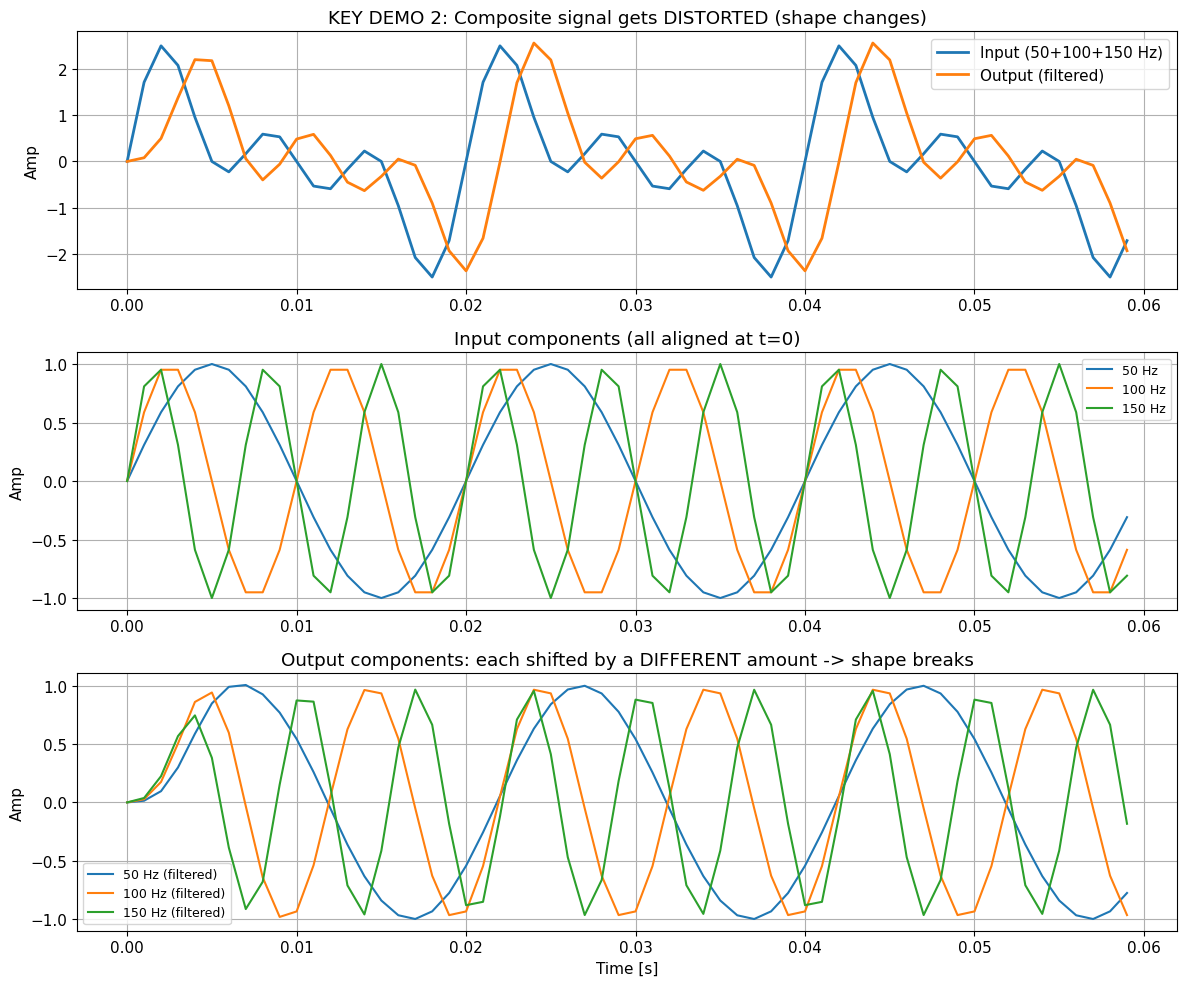

아래 그림: 성분들이 제각각 밀려서 정렬이 깨짐
=> 합쳐진 파형(위)의 모양이 입력과 달라짐 = 위상 왜곡의 결과


In [16]:
b, a = butter_lp(200, order=4)     # 셋 다 통과대역에 두어 크기 변화 최소화

t = np.arange(0, 0.06, 1/FS)
comps = [np.sin(2*np.pi*f*t) for f in (50, 100, 150)]
x = sum(comps)                              # 세 성분 합친 신호
y = signal.lfilter(b, a, x)

# 각 성분을 따로 필터에 통과 (각각 얼마나 밀리는지 보려고)
comps_filtered = [signal.lfilter(b, a, c) for c in comps]

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(t, x, lw=2, label='Input (50+100+150 Hz)')
axes[0].plot(t, y, lw=2, label='Output (filtered)')
axes[0].set_title('KEY DEMO 2: Composite signal gets DISTORTED (shape changes)')
axes[0].set_ylabel('Amp'); axes[0].legend()

for c, f0 in zip(comps, (50, 100, 150)):
    axes[1].plot(t, c, lw=1.5, label=f'{f0} Hz')
axes[1].set_title('Input components (all aligned at t=0)')
axes[1].set_ylabel('Amp'); axes[1].legend(fontsize=9)

for cf, f0 in zip(comps_filtered, (50, 100, 150)):
    axes[2].plot(t, cf, lw=1.5, label=f'{f0} Hz (filtered)')
axes[2].set_title('Output components: each shifted by a DIFFERENT amount -> shape breaks')
axes[2].set_xlabel('Time [s]'); axes[2].set_ylabel('Amp'); axes[2].legend(fontsize=9)

plt.tight_layout(); plt.show()

print("아래 그림: 성분들이 제각각 밀려서 정렬이 깨짐")
print("=> 합쳐진 파형(위)의 모양이 입력과 달라짐 = 위상 왜곡의 결과")

---
# ★★★ 핵심 데모 3 — "임펄스가 시간축으로 퍼진다"

**Goeun이 이해하고 싶어한 것: 임펄스가 필터를 지나면 왜 퍼지나?**

**답**: 필터는 **과거 값을 기억해서 섞기 때문**이다.
- 입력은 한 샘플만 1인데 (뾰족)
- IIR 필터는 그 값을 피드백으로 계속 되먹여서 → **여러 샘플에 걸쳐 출력이 나옴** (퍼짐)
- 이 퍼진 출력이 곧 **임펄스 응답 h[n]**

그리고 **차수(order)를 올릴수록 더 오래 퍼진다** (극점이 많아져 기억이 길어짐).


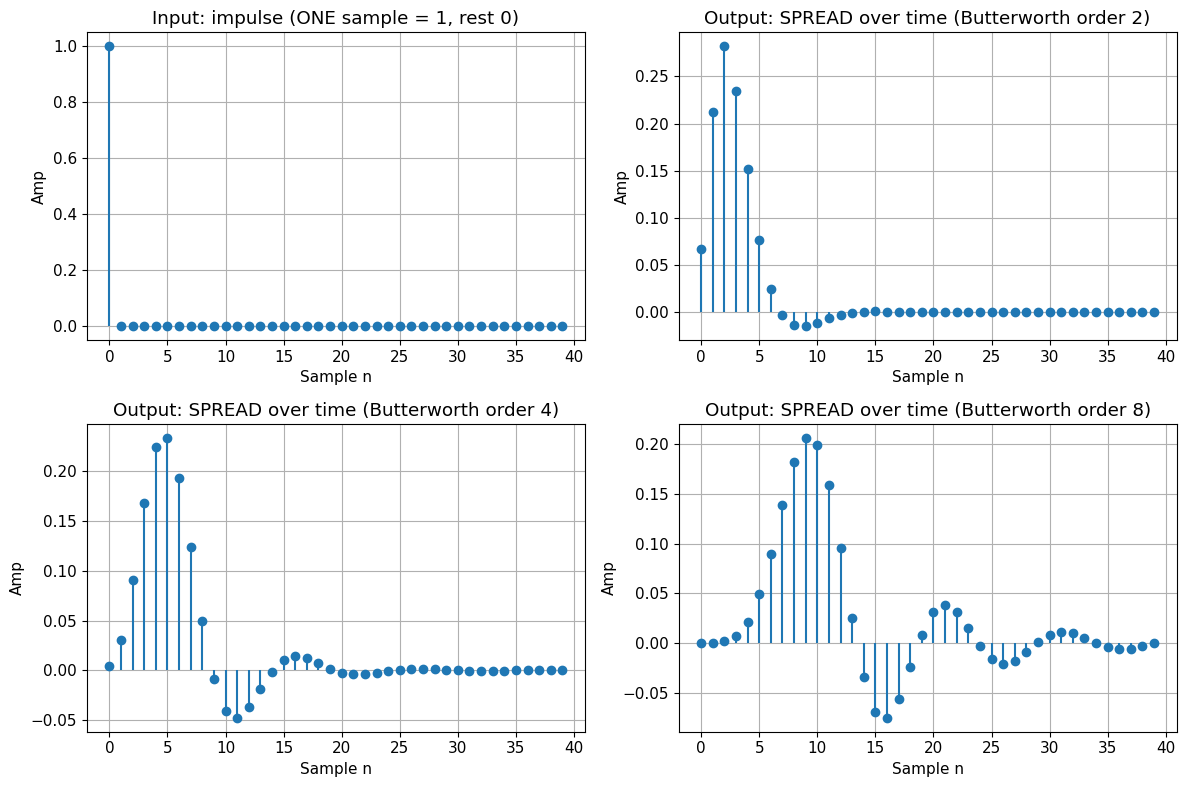

입력: 1샘플만 1 (뾰족)
출력: 여러 샘플에 걸쳐 퍼짐 = 임펄스 응답 h[n]
=> 필터가 과거를 기억(피드백)해서 되먹이기 때문
=> 차수가 높을수록 극점이 많아 더 오래 퍼짐


In [17]:
N = 200
impulse = np.zeros(N); impulse[0] = 1
n = np.arange(N)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 입력 임펄스
axes[0,0].stem(n[:40], impulse[:40], basefmt=' ')
axes[0,0].set_title('Input: impulse (ONE sample = 1, rest 0)')
axes[0,0].set_xlabel('Sample n'); axes[0,0].set_ylabel('Amp')

# 차수별 임펄스 응답
for order, ax in zip([2, 4, 8], [axes[0,1], axes[1,0], axes[1,1]]):
    b, a = butter_lp(100, order=order)
    h = signal.lfilter(b, a, impulse)
    ax.stem(n[:40], h[:40], basefmt=' ')
    ax.set_title(f'Output: SPREAD over time (Butterworth order {order})')
    ax.set_xlabel('Sample n'); ax.set_ylabel('Amp')

plt.tight_layout(); plt.show()

print("입력: 1샘플만 1 (뾰족)")
print("출력: 여러 샘플에 걸쳐 퍼짐 = 임펄스 응답 h[n]")
print("=> 필터가 과거를 기억(피드백)해서 되먹이기 때문")
print("=> 차수가 높을수록 극점이 많아 더 오래 퍼짐")

### 왜 퍼지나 — 차분방정식으로 직접 확인

1차 필터 $y[n] = b_0 x[n] + b_1 x[n-1] - a_1 y[n-1]$ 에 임펄스를 넣으면:

- $y[0]$: 입력 1이 들어와 출력 발생
- $y[1]$: 입력은 이미 0인데, **$y[0]$이 피드백으로 되먹여져** 출력 발생
- $y[2]$: 다시 $y[1]$이 되먹여짐 ... 계속

**입력이 끝나도 피드백이 출력을 계속 만든다** → 이것이 "퍼짐"의 정체.


In [18]:
b, a = butter_lp(100, order=1)
h = signal.lfilter(b, a, impulse)

print("1차 Butterworth 임펄스 응답 (직접 계산 확인):")
print(f"b = {b},  a = {a}\n")
print(" n | input x[n] | output h[n] | (설명)")
print("---+------------+-------------+------------------")
for i in range(6):
    note = "입력 있음" if i == 0 else "입력 0인데 피드백으로 출력 발생!"
    print(f"{i:>2} |   {impulse[i]:>6.1f}   |  {h[i]:>9.5f}  | {note}")
print("\n=> 입력이 사라져도 출력이 계속 나옴 = 퍼짐 = IIR(Infinite Impulse Response)")

1차 Butterworth 임펄스 응답 (직접 계산 확인):
b = [0.2452 0.2452],  a = [ 1.     -0.5095]

 n | input x[n] | output h[n] | (설명)
---+------------+-------------+------------------
 0 |      1.0   |    0.24524  | 입력 있음
 1 |      0.0   |    0.37019  | 입력 0인데 피드백으로 출력 발생!
 2 |      0.0   |    0.18862  | 입력 0인데 피드백으로 출력 발생!
 3 |      0.0   |    0.09611  | 입력 0인데 피드백으로 출력 발생!
 4 |      0.0   |    0.04897  | 입력 0인데 피드백으로 출력 발생!
 5 |      0.0   |    0.02495  | 입력 0인데 피드백으로 출력 발생!

=> 입력이 사라져도 출력이 계속 나옴 = 퍼짐 = IIR(Infinite Impulse Response)


---
## V6 — 슬라이더 (주파수, Cutoff, Order, Q)

인터랙티브하게 파라미터를 바꿔가며 magnitude/phase/group delay가 어떻게 변하는지 관찰.
(`ipywidgets` 필요. 없으면 `pip install ipywidgets`)


In [19]:
from ipywidgets import interact, IntSlider, FloatSlider

def explore(cutoff=100, order=4, sig_freq=50):
    b, a = butter_lp(cutoff, order=order)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # 시간영역
    t, x = make_sine(sig_freq, dur=0.1)
    y = signal.lfilter(b, a, x)
    axes[0,0].plot(t, x, label='Input', lw=1.5, alpha=0.7)
    axes[0,0].plot(t, y, label='Output', lw=2)
    axes[0,0].set_title(f'Time domain ({sig_freq} Hz)')
    axes[0,0].set_xlabel('Time [s]'); axes[0,0].legend(); axes[0,0].set_ylim(-1.4, 1.4)

    # magnitude
    plot_mag(b, a, ax=axes[0,1])
    axes[0,1].axvline(cutoff, color='r', ls='--', alpha=0.6)
    axes[0,1].axvline(sig_freq, color='g', ls=':', alpha=0.8)
    axes[0,1].set_title('Magnitude')

    # phase
    plot_phase(b, a, ax=axes[1,0])
    axes[1,0].axvline(cutoff, color='r', ls='--', alpha=0.6)
    axes[1,0].set_title('Phase')

    # group delay
    plot_gdelay(b, a, ax=axes[1,1])
    axes[1,1].axvline(cutoff, color='r', ls='--', alpha=0.6)
    axes[1,1].set_title('Group delay (flat = same delay for all freqs)')

    plt.tight_layout(); plt.show()

interact(explore,
         cutoff=IntSlider(100, 20, 400, 10, description='Cutoff [Hz]'),
         order=IntSlider(4, 1, 10, 1, description='Order'),
         sig_freq=IntSlider(50, 10, 300, 10, description='Signal [Hz]'));

interactive(children=(IntSlider(value=100, description='Cutoff [Hz]', max=400, min=20, step=10), IntSlider(val…

## V7 — Butterworth / Chebyshev / Bessel / Elliptic 전환

**각 필터의 성격을 비교** (특히 group delay를 주목!):

| 필터 | 특징 |
|---|---|
| **Butterworth** | 통과대역 최대 평탄 (maximally flat), 무난 |
| **Chebyshev I** | 통과대역 ripple 허용, 더 가파름 |
| **Bessel** | **group delay가 가장 평평** → 위상 왜곡 최소, 대신 완만 |
| **Elliptic** | 양쪽 ripple 허용, 가장 가파름 |

**Bessel의 group delay가 평평한 것**을 확인하세요 — "모든 주파수를 같은 시간 지연"에 가장 가까운 IIR이에요.


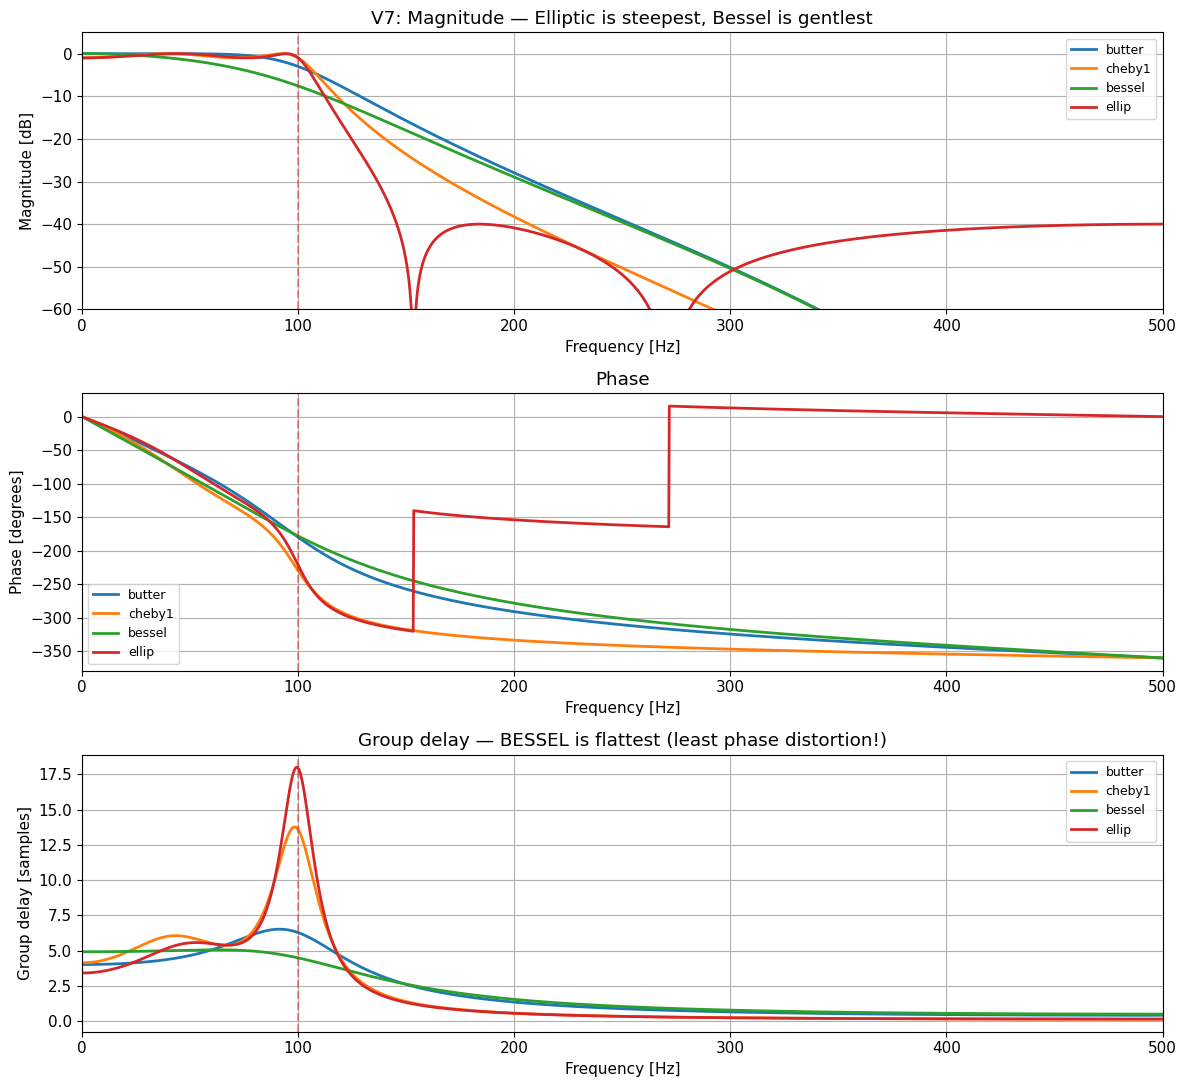

Group delay가 평평할수록 -> 모든 주파수가 같은 시간 지연 -> 파형 보존
Bessel이 가장 평평 => IIR 중 위상 왜곡이 가장 적음


In [20]:
def make_filter(kind, cutoff=100, order=4, rp=1, rs=40, fs=FS):
    wn = cutoff/(fs/2)
    if kind == 'butter':
        return signal.butter(order, wn, btype='low')
    if kind == 'cheby1':
        return signal.cheby1(order, rp, wn, btype='low')
    if kind == 'bessel':
        return signal.bessel(order, wn, btype='low', norm='phase')
    if kind == 'ellip':
        return signal.ellip(order, rp, rs, wn, btype='low')
    raise ValueError(kind)

kinds = ['butter', 'cheby1', 'bessel', 'ellip']

fig, axes = plt.subplots(3, 1, figsize=(12, 11))
for kind in kinds:
    b, a = make_filter(kind, cutoff=100, order=4)
    plot_mag(b, a, ax=axes[0], label=kind)
    plot_phase(b, a, ax=axes[1], label=kind)
    plot_gdelay(b, a, ax=axes[2], label=kind)

axes[0].set_title('V7: Magnitude — Elliptic is steepest, Bessel is gentlest')
axes[1].set_title('Phase')
axes[2].set_title('Group delay — BESSEL is flattest (least phase distortion!)')
for ax in axes:
    ax.axvline(100, color='r', ls='--', alpha=0.4)
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("Group delay가 평평할수록 -> 모든 주파수가 같은 시간 지연 -> 파형 보존")
print("Bessel이 가장 평평 => IIR 중 위상 왜곡이 가장 적음")

## V8 — Impulse Response & Step Response

- **Impulse response**: 임펄스(1샘플) → 시간축으로 **퍼짐** (앞의 핵심 데모 3)
- **Step response**: 계단 입력(0→1) → 목표값에 어떻게 **도달**하는가
  - overshoot(넘침), ringing(출렁임)이 보임
  - Elliptic/Chebyshev는 ringing 큼, Bessel은 깔끔 (group delay가 평평해서!)


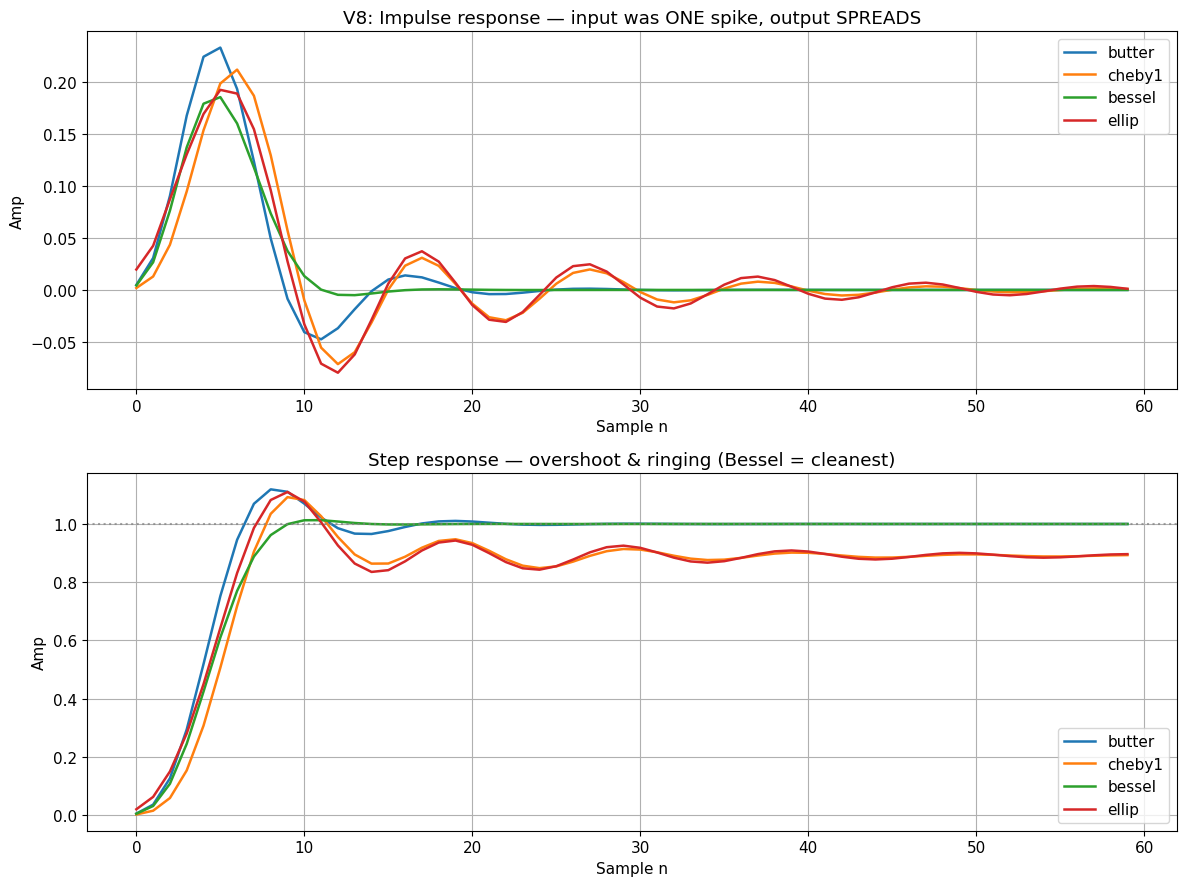

Impulse: 1샘플 입력 -> 여러 샘플로 퍼짐 (필터가 과거를 기억해서)
Step: 목표 1에 도달하는 방식이 필터마다 다름
  - Elliptic/Chebyshev: ringing 심함 (위상 왜곡 큼)
  - Bessel: 깔끔 (group delay 평평 -> 위상 왜곡 적음)


In [21]:
N = 200
impulse = np.zeros(N); impulse[0] = 1
step = np.ones(N)
n = np.arange(N)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

for kind in kinds:
    b, a = make_filter(kind, cutoff=100, order=4)
    h = signal.lfilter(b, a, impulse)
    s = signal.lfilter(b, a, step)
    axes[0].plot(n[:60], h[:60], lw=1.8, label=kind)
    axes[1].plot(n[:60], s[:60], lw=1.8, label=kind)

axes[0].set_title('V8: Impulse response — input was ONE spike, output SPREADS')
axes[0].set_xlabel('Sample n'); axes[0].set_ylabel('Amp'); axes[0].legend()

axes[1].axhline(1.0, color='gray', ls=':', alpha=0.7)
axes[1].set_title('Step response — overshoot & ringing (Bessel = cleanest)')
axes[1].set_xlabel('Sample n'); axes[1].set_ylabel('Amp'); axes[1].legend()

plt.tight_layout(); plt.show()

print("Impulse: 1샘플 입력 -> 여러 샘플로 퍼짐 (필터가 과거를 기억해서)")
print("Step: 목표 1에 도달하는 방식이 필터마다 다름")
print("  - Elliptic/Chebyshev: ringing 심함 (위상 왜곡 큼)")
print("  - Bessel: 깔끔 (group delay 평평 -> 위상 왜곡 적음)")

---
## 정리

**1. 임펄스가 시간축으로 퍼지는 이유**
> 필터는 **과거 값을 피드백으로 되먹인다**. 입력이 1샘플뿐이어도, 그 값이 계속 되먹여져서 여러 샘플에 걸쳐 출력이 나온다. 이 퍼진 출력이 **임펄스 응답 h[n]**이고, 차수(극점)가 많을수록 더 오래 퍼진다. (IIR = Infinite Impulse Response)

**2. 주파수마다 위상 지연이 다른 이유**
> IIR 필터는 각 주파수를 **다른 시간만큼** 밀어낸다 (핵심 데모 1에서 측정 확인). 그래서:
> - **phase response**가 주파수마다 다른 값 (직선이 아닌 곡선)
> - **group delay**가 평평하지 않음 (= 주파수별 지연 시간이 다름)
> - 여러 주파수가 섞인 신호는 성분들이 제각각 밀려 **파형이 일그러짐** (핵심 데모 2)
>
> 그리고 **Bessel**이 group delay가 가장 평평 → IIR 중 위상 왜곡이 최소 (V7).

**다음 단계**: linear phase가 꼭 필요하면 FIR로 가야 함 (IIR로는 불가능).
